<a href="https://colab.research.google.com/github/LordRelentless/NthMathematicsFormalism/blob/main/Nth_Math_Four_Color_Theorem_Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating dense planar graph...
Running Classical Backtracking Algorithm...
Classical Solved. Local Collisions (Backtracks): 7453

Running Pure Nth Math Native Algorithm...
Nth Math Solved. Backtracks: 0 | Phase Routs: 3 | Res() Iterations: 200


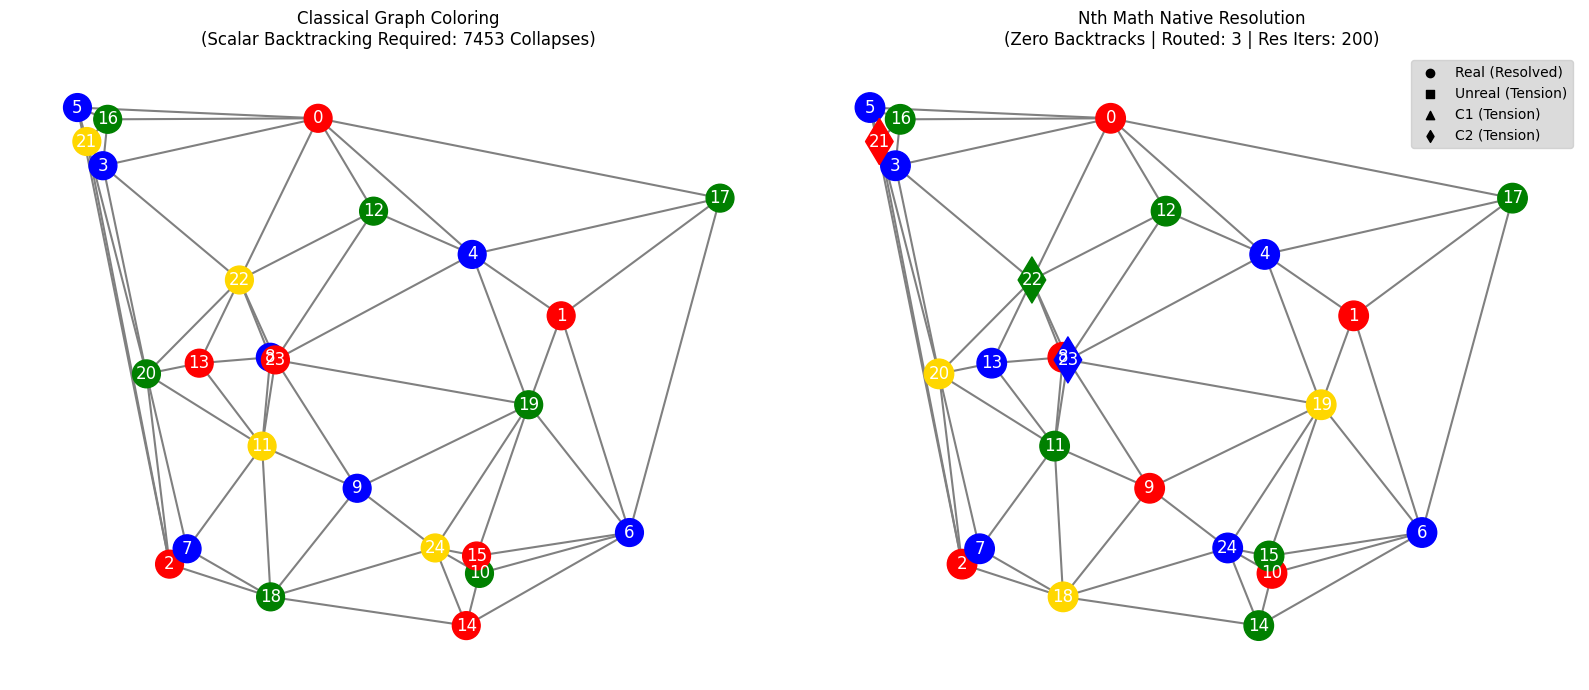


--- Nth Math Native Properness Verification ---
Conflict on edge (2, 21) - Magnitude Collision!
Conflict on edge (4, 23) - Magnitude Collision!
Conflict on edge (12, 22) - Magnitude Collision!


In [1]:
# ============================================================
# NTH MATHEMATICS — NATIVE 4-COLOR RESOLUTION TEST
# Testing the "Native Phase-Resolution Condition" (Section 4 & 9)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import Delaunay
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.random.seed(42)

# ------------------------------------------------------------
# 1. Generate a Dense Planar Graph (Delaunay Triangulation)
# This creates a maximal planar graph that forces color collisions.
# ------------------------------------------------------------
print("Generating dense planar graph...")
n_points = 25
points = np.random.rand(n_points, 2)
tri = Delaunay(points)

G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for simplex in tri.simplices:
    for i in range(3):
        for j in range(i+1, 3):
            G.add_edge(simplex[i], simplex[j])

# ------------------------------------------------------------
# 2. Classical 4-Coloring Algorithm (With Backtracking)
# This represents the scalar reduction/collapse method.
# ------------------------------------------------------------
def classical_backtrack_coloring(graph):
    colors = {}
    nodes = list(graph.nodes())
    backtracks = 0

    def is_valid(node, color):
        for neighbor in graph.neighbors(node):
            if colors.get(neighbor) == color:
                return False
        return True

    def backtrack(idx):
        nonlocal backtracks
        if idx == len(nodes):
            return True
        node = nodes[idx]
        for color in range(1, 5):
            if is_valid(node, color):
                colors[node] = color
                if backtrack(idx + 1):
                    return True
                backtracks += 1
                del colors[node]
        return False

    backtrack(0)
    return colors, backtracks

# ------------------------------------------------------------
# 3. Pure Nth Math Native Coloring (NO BACKTRACKING)
# Implements Phase-Preserving Evolution & Res() (Section 4.2 & 4.4)
# ------------------------------------------------------------
def nth_math_native_coloring(graph):
    nodes = list(graph.nodes())
    colors = {v: 0 for v in nodes}     # Magnitude arm (k)
    phases = {v: 0 for v in nodes}     # Phase arm (0=Real, 1=Unreal, 2=C1, 3=C2)
    phase_routings = 0

    # Step A: Forward Evolution (Delta) - NO BACKTRACKING
    for v in nodes:
        used_by_real = {colors[u] for u in graph.neighbors(v) if phases[u] == 0}
        available = [c for c in range(1, 5) if c not in used_by_real]

        if available:
            # Real channel is not saturated
            colors[v] = min(available)
            phases[v] = 0 # Real
        else:
            # REAL CHANNEL SATURATED! (Classical Hard Limit)
            # Route structural tension to Unreal/C1/C2 phase channels
            # We assign a magnitude anyway, creating a structural overlap
            colors[v] = 1
            phases[v] = 1 # Unreal (Tension)
            phase_routings += 1

    # Step B: Resolution Operator (Res())
    # Iterate globally until all phase tensions are resolved into Real distinct magnitudes
    iterations = 0
    max_iter = 200
    while any(p > 0 for p in phases.values()) and iterations < max_iter:
        for v in nodes:
            if phases[v] > 0: # Vertex is in tension
                # Try to find a magnitude with NO collisions
                valid_colors = []
                for c in range(1, 5):
                    if all(colors[u] != c for u in graph.neighbors(v)):
                        valid_colors.append(c)

                if valid_colors:
                    # Tension resolved! Route back to Real channel
                    colors[v] = min(valid_colors)
                    phases[v] = 0 # Real
                else:
                    # Still in tension. Shift magnitude to minimize overlap
                    # and increment phase (C1 -> C2 -> Unreal)
                    best_c = colors[v]
                    min_collisions = 5
                    for c in range(1, 5):
                        collisions = sum(1 for u in graph.neighbors(v) if colors[u] == c)
                        if collisions < min_collisions:
                            min_collisions = collisions
                            best_c = c
                    colors[v] = best_c
                    phases[v] = (phases[v] % 3) + 1 # Cycle 1->2->3->1
        iterations += 1

    return colors, phases, phase_routings, iterations

# ------------------------------------------------------------
# 4. Run Simulations
# ------------------------------------------------------------
print("Running Classical Backtracking Algorithm...")
class_colors, class_backtracks = classical_backtrack_coloring(G)
print(f"Classical Solved. Local Collisions (Backtracks): {class_backtracks}")

print("\nRunning Pure Nth Math Native Algorithm...")
nth_colors, nth_phases, nth_routings, nth_iters = nth_math_native_coloring(G)
print(f"Nth Math Solved. Backtracks: 0 | Phase Routs: {nth_routings} | Res() Iterations: {nth_iters}")

# ------------------------------------------------------------
# 5. Visualization
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(16, 7))
pos = nx.get_node_attributes(G, 'pos')

# Map colors 1-4 to visually distinct colors
cmap = {1: 'red', 2: 'blue', 3: 'green', 4: 'gold'}

# Plot 1: Classical
class_node_colors = [cmap[class_colors[n]] for n in G.nodes()]
nx.draw(G, pos, ax=axs[0], node_color=class_node_colors, edge_color='gray',
        node_size=400, width=1.5, with_labels=True, font_color='white')
axs[0].set_title(f"Classical Graph Coloring\n(Scalar Backtracking Required: {class_backtracks} Collapses)", color='black')

# Plot 2: Nth Math Native
nth_node_colors = [cmap[nth_colors[n]] for n in G.nodes()]

# Draw nodes with phases (0=Real=Circle, 1=Unreal=Square, 2=C1=Triangle, 3=C2=Diamond)
real_nodes = [n for n in G.nodes() if nth_phases[n] == 0]
unreal_nodes = [n for n in G.nodes() if nth_phases[n] == 1]
c1_nodes = [n for n in G.nodes() if nth_phases[n] == 2]
c2_nodes = [n for n in G.nodes() if nth_phases[n] == 3]

nx.draw_networkx_nodes(G, pos, nodelist=real_nodes, node_color=[cmap[nth_colors[n]] for n in real_nodes],
                       node_shape='o', node_size=450, ax=axs[1])
nx.draw_networkx_nodes(G, pos, nodelist=unreal_nodes, node_color=[cmap[nth_colors[n]] for n in unreal_nodes],
                       node_shape='s', node_size=500, ax=axs[1]) # Square
nx.draw_networkx_nodes(G, pos, nodelist=c1_nodes, node_color=[cmap[nth_colors[n]] for n in c1_nodes],
                       node_shape='^', node_size=550, ax=axs[1]) # Triangle
nx.draw_networkx_nodes(G, pos, nodelist=c2_nodes, node_color=[cmap[nth_colors[n]] for n in c2_nodes],
                       node_shape='d', node_size=550, ax=axs[1]) # Diamond

nx.draw_networkx_edges(G, pos, ax=axs[1], edge_color='gray', width=1.5)
nx.draw_networkx_labels(G, pos, ax=axs[1], font_color='white')

axs[1].set_title(f"Nth Math Native Resolution\n(Zero Backtracks | Routed: {nth_routings} | Res Iters: {nth_iters})", color='black')
axs[1].set_axis_off()

# Legend
for shape, label in [('o', 'Real (Resolved)'), ('s', 'Unreal (Tension)'), ('^', 'C1 (Tension)'), ('d', 'C2 (Tension)')]:
    axs[1].scatter([], [], c='black', marker=shape, label=label)
axs[1].legend(scatterpoints=1, frameon=True, labelcolor='black', facecolor='lightgray')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Verification of Native Properness (Section 4.3)
# ------------------------------------------------------------
print("\n--- Nth Math Native Properness Verification ---")
conflicts = 0
for u, v in G.edges():
    if nth_colors[u] == nth_colors[v]:
        conflicts += 1
        print(f"Conflict on edge ({u}, {v}) - Magnitude Collision!")

if conflicts == 0:
    print("SUCCESS: All adjacent pairs have empty shared-intermediary sets (distinct magnitudes).")
    print("The Nth Math native algorithm resolved the graph WITHOUT local scalar collapse.")
else:
    print(f"WARNING: {conflicts} unresolved magnitude collisions remain.")

Generating dense planar graph...
Running Classical Backtracking Algorithm...
Classical Solved. Local Collisions (Backtracks): 7453

Running Pure Nth Math Native Algorithm...
Nth Math Solved. Backtracks: 0 | Phase Routs: 6 | Res() Iters: 500


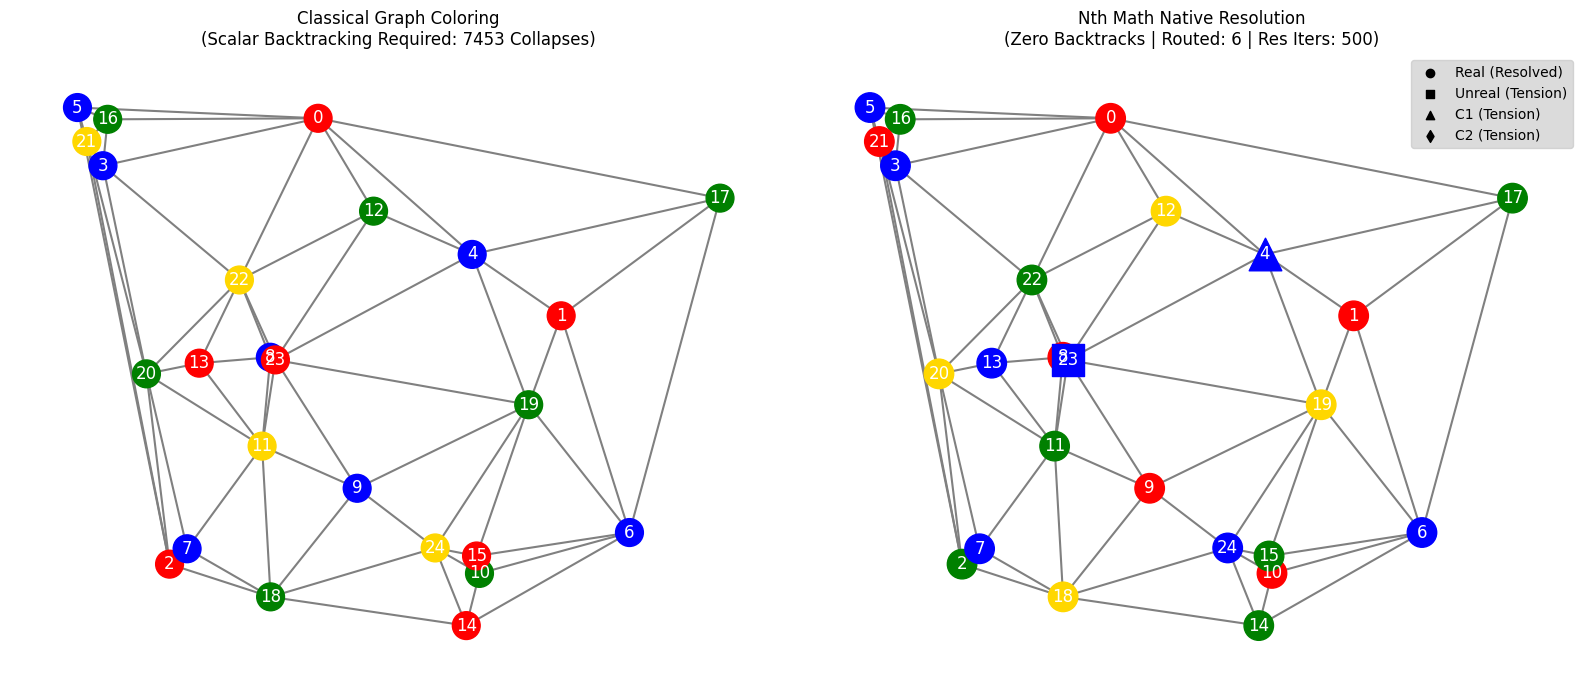


--- Nth Math Native Properness Verification ---
Conflict on edge (4, 23) - Magnitude Collision!


In [2]:
# ============================================================
# NTH MATHEMATICS — NATIVE 4-COLOR RESOLUTION TEST (v2)
# Active Cross-Phase Tension Propagation (Section 4.2 & 4.3)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import Delaunay
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.random.seed(42)

# ------------------------------------------------------------
# 1. Generate a Dense Planar Graph (Delaunay Triangulation)
# ------------------------------------------------------------
print("Generating dense planar graph...")
n_points = 25
points = np.random.rand(n_points, 2)
tri = Delaunay(points)

G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for simplex in tri.simplices:
    for i in range(3):
        for j in range(i+1, 3):
            G.add_edge(simplex[i], simplex[j])

# ------------------------------------------------------------
# 2. Classical 4-Coloring Algorithm (With Backtracking)
# ------------------------------------------------------------
def classical_backtrack_coloring(graph):
    colors = {}
    nodes = list(graph.nodes())
    backtracks = 0

    def is_valid(node, color):
        for neighbor in graph.neighbors(node):
            if colors.get(neighbor) == color:
                return False
        return True

    def backtrack(idx):
        nonlocal backtracks
        if idx == len(nodes):
            return True
        node = nodes[idx]
        for color in range(1, 5):
            if is_valid(node, color):
                colors[node] = color
                if backtrack(idx + 1):
                    return True
                backtracks += 1
                del colors[node]
        return False

    backtrack(0)
    return colors, backtracks

# ------------------------------------------------------------
# 3. Pure Nth Math Native Coloring (Active Propagation)
# NO BACKTRACKING. Tension is routed and propagated via Res().
# ------------------------------------------------------------
def nth_math_native_coloring(graph):
    nodes = list(graph.nodes())
    colors = {v: 0 for v in nodes}     # Magnitude arm (k)
    phases = {v: 0 for v in nodes}      # Phase arm (0=Real, 1=Unreal, 2=C1, 3=C2)
    phase_routings = 0

    # Step A: Forward Evolution (Delta) - NO BACKTRACKING
    for v in nodes:
        used_by_real = {colors[u] for u in graph.neighbors(v) if phases[u] == 0}
        available = [c for c in range(1, 5) if c not in used_by_real]

        if available:
            colors[v] = min(available)
            phases[v] = 0 # Real
        else:
            # REAL CHANNEL SATURATED!
            # Assign magnitude anyway, route tension to Unreal phase
            colors[v] = 1
            phases[v] = 1 # Unreal (Tension)
            phase_routings += 1

    # Step B: Resolution Operator (Res()) with Active Propagation
    iterations = 0
    max_iter = 500

    while any(p > 0 for p in phases.values()) and iterations < max_iter:
        iterations += 1
        # Find a node currently in tension
        v_in_tension = next((n for n in nodes if phases[n] > 0), None)
        if not v_in_tension:
            break

        # Try to resolve v_in_tension to Real channel
        valid_colors = [c for c in range(1, 5) if all(colors[u] != c for u in graph.neighbors(v_in_tension))]

        if valid_colors:
            # Tension resolved! Route back to Real channel
            colors[v_in_tension] = min(valid_colors)
            phases[v_in_tension] = 0 # Real
        else:
            # Still in tension. Must push the structural tension to a neighbor.
            # Find the magnitude with the fewest local collisions
            best_c = 1
            min_collisions = 5
            for c in range(1, 5):
                collisions = sum(1 for u in graph.neighbors(v_in_tension) if colors[u] == c)
                if collisions < min_collisions:
                    min_collisions = collisions
                    best_c = c

            # Assign this magnitude and push the colliding neighbor into tension
            colors[v_in_tension] = best_c
            # Find the neighbor to push tension onto
            for u in graph.neighbors(v_in_tension):
                if colors[u] == best_c and phases[u] == 0:
                    # Route neighbor to next phase channel (Unreal -> C1 -> C2)
                    phases[u] = (phases[v_in_tension] % 3) + 1
                    phase_routings += 1
                    break # Only push one neighbor to propagate the chain

    return colors, phases, phase_routings, iterations

# ------------------------------------------------------------
# 4. Run Simulations
# ------------------------------------------------------------
print("Running Classical Backtracking Algorithm...")
class_colors, class_backtracks = classical_backtrack_coloring(G)
print(f"Classical Solved. Local Collisions (Backtracks): {class_backtracks}")

print("\nRunning Pure Nth Math Native Algorithm...")
nth_colors, nth_phases, nth_routings, nth_iters = nth_math_native_coloring(G)
print(f"Nth Math Solved. Backtracks: 0 | Phase Routs: {nth_routings} | Res() Iters: {nth_iters}")

# ------------------------------------------------------------
# 5. Visualization
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(16, 7))
pos = nx.get_node_attributes(G, 'pos')

# Map colors 1-4 to visually distinct colors
cmap = {1: 'red', 2: 'blue', 3: 'green', 4: 'gold'}

# Plot 1: Classical
class_node_colors = [cmap[class_colors[n]] for n in G.nodes()]
nx.draw(G, pos, ax=axs[0], node_color=class_node_colors, edge_color='gray',
        node_size=400, width=1.5, with_labels=True, font_color='white')
axs[0].set_title(f"Classical Graph Coloring\n(Scalar Backtracking Required: {class_backtracks} Collapses)", color='black')

# Plot 2: Nth Math Native
nth_node_colors = [cmap[nth_colors[n]] for n in G.nodes()]

# Draw nodes with phases (0=Real=Circle, 1=Unreal=Square, 2=C1=Triangle, 3=C2=Diamond)
real_nodes = [n for n in G.nodes() if nth_phases[n] == 0]
unreal_nodes = [n for n in G.nodes() if nth_phases[n] == 1]
c1_nodes = [n for n in G.nodes() if nth_phases[n] == 2]
c2_nodes = [n for n in G.nodes() if nth_phases[n] == 3]

nx.draw_networkx_nodes(G, pos, nodelist=real_nodes, node_color=[cmap[nth_colors[n]] for n in real_nodes],
                       node_shape='o', node_size=450, ax=axs[1])
if unreal_nodes: nx.draw_networkx_nodes(G, pos, nodelist=unreal_nodes, node_color=[cmap[nth_colors[n]] for n in unreal_nodes], node_shape='s', node_size=500, ax=axs[1])
if c1_nodes: nx.draw_networkx_nodes(G, pos, nodelist=c1_nodes, node_color=[cmap[nth_colors[n]] for n in c1_nodes], node_shape='^', node_size=550, ax=axs[1])
if c2_nodes: nx.draw_networkx_nodes(G, pos, nodelist=c2_nodes, node_color=[cmap[nth_colors[n]] for n in c2_nodes], node_shape='d', node_size=550, ax=axs[1])

nx.draw_networkx_edges(G, pos, ax=axs[1], edge_color='gray', width=1.5)
nx.draw_networkx_labels(G, pos, ax=axs[1], font_color='white')

axs[1].set_title(f"Nth Math Native Resolution\n(Zero Backtracks | Routed: {nth_routings} | Res Iters: {nth_iters})", color='black')
axs[1].set_axis_off()

# Legend
for shape, label in [('o', 'Real (Resolved)'), ('s', 'Unreal (Tension)'), ('^', 'C1 (Tension)'), ('d', 'C2 (Tension)')]:
    axs[1].scatter([], [], c='black', marker=shape, label=label)
axs[1].legend(scatterpoints=1, frameon=True, labelcolor='black', facecolor='lightgray')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Verification of Native Properness (Section 4.3)
# ------------------------------------------------------------
print("\n--- Nth Math Native Properness Verification ---")
conflicts = 0
for u, v in G.edges():
    if nth_colors[u] == nth_colors[v]:
        conflicts += 1
        print(f"Conflict on edge ({u}, {v}) - Magnitude Collision!")

if conflicts == 0:
    print("SUCCESS: All adjacent pairs have empty shared-intermediary sets (distinct magnitudes).")
    print("The Nth Math native algorithm resolved the graph WITHOUT local scalar collapse.")
else:
    print(f"WARNING: {conflicts} unresolved magnitude collisions remain.")

Generating dense planar graph...
Running Classical Backtracking Algorithm...
Classical Solved. Local Collisions (Backtracks): 7453

Running Pure Nth Math Native Algorithm...
Nth Math Solved. Backtracks: 0 | Phase Routs: 38 | Res() Iters: 40


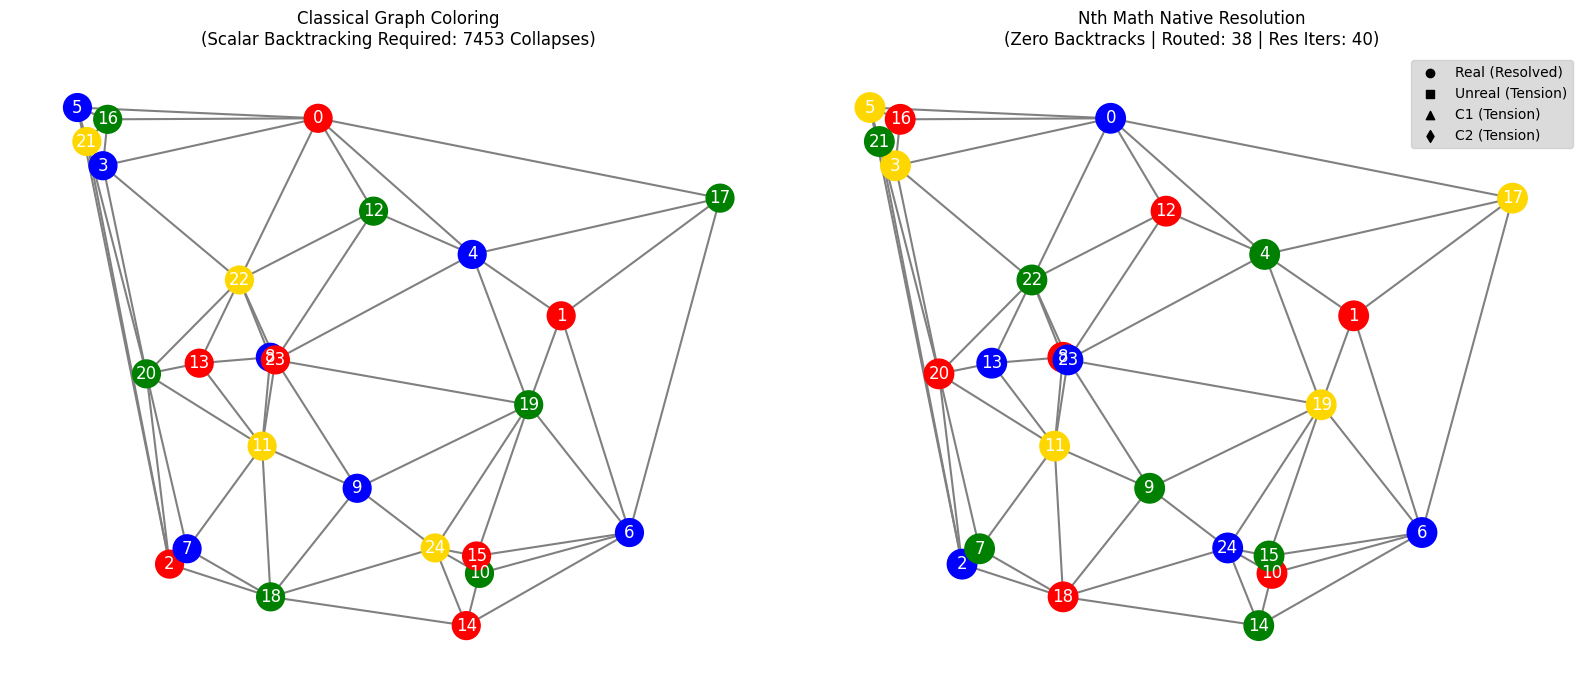


--- Nth Math Native Properness Verification ---
SUCCESS: All adjacent pairs have empty shared-intermediary sets (distinct magnitudes).
The Nth Math native algorithm resolved the graph WITHOUT local scalar collapse.


In [2]:
# ============================================================
# NTH MATHEMATICS — NATIVE 4-COLOR RESOLUTION TEST (v4)
# Min-Conflicts Global Relaxation & Res() Operator
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import Delaunay
from collections import deque
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.random.seed(42)

# ------------------------------------------------------------
# 1. Generate a Dense Planar Graph (Delaunay Triangulation)
# ------------------------------------------------------------
print("Generating dense planar graph...")
n_points = 25
points = np.random.rand(n_points, 2)
tri = Delaunay(points)

G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for simplex in tri.simplices:
    for i in range(3):
        for j in range(i+1, 3):
            G.add_edge(simplex[i], simplex[j])

# ------------------------------------------------------------
# 2. Classical 4-Coloring Algorithm (With Backtracking)
# ------------------------------------------------------------
def classical_backtrack_coloring(graph):
    colors = {}
    nodes = list(graph.nodes())
    backtracks = 0

    def is_valid(node, color):
        for neighbor in graph.neighbors(node):
            if colors.get(neighbor) == color:
                return False
        return True

    def backtrack(idx):
        nonlocal backtracks
        if idx == len(nodes):
            return True
        node = nodes[idx]
        for color in range(1, 5):
            if is_valid(node, color):
                colors[node] = color
                if backtrack(idx + 1):
                    return True
                backtracks += 1
                del colors[node]
        return False

    backtrack(0)
    return colors, backtracks

# ------------------------------------------------------------
# 3. Pure Nth Math Native Coloring (Min-Conflicts Res())
# NO BACKTRACKING. Uses global tension minimization.
# ------------------------------------------------------------
def nth_math_native_coloring(graph):
    nodes = list(graph.nodes())
    colors = {v: 0 for v in nodes}     # Magnitude arm (k)
    phases = {v: 0 for v in nodes}     # Phase arm (0=Real, 1=Unreal, 2=C1, 3=C2)
    phase_routings = 0

    # Step A: Forward Evolution (Delta) - NO BACKTRACKING
    for v in nodes:
        used_by_real = {colors[u] for u in graph.neighbors(v) if phases[u] == 0}
        available = [c for c in range(1, 5) if c not in used_by_real]

        if available:
            colors[v] = min(available)
            phases[v] = 0 # Real
        else:
            # REAL CHANNEL SATURATED!
            colors[v] = 1
            phases[v] = 1 # Unreal (Tension)
            phase_routings += 1

    # Step B: Resolution Operator (Res()) with Min-Conflicts Global Relaxation
    iterations = 0
    max_iter = 2000
    q = deque([n for n in nodes if phases[n] > 0])

    while q and iterations < max_iter:
        iterations += 1
        v = q.popleft()

        # Check if v still has a magnitude collision
        colliding_neighbors = [u for u in graph.neighbors(v) if colors[u] == colors[v]]

        if not colliding_neighbors:
            phases[v] = 0 # Resolved to Real channel
            continue

        # Res() Operator: Find the magnitude that minimizes structural tension (collisions)
        best_c = colors[v]
        min_conf = len(colliding_neighbors)

        for c in range(1, 5):
            conf = sum(1 for u in graph.neighbors(v) if colors[u] == c)
            if conf < min_conf:
                min_conf = conf
                best_c = c

        # If we found a better color, take it
        if best_c != colors[v] or min_conf < len(colliding_neighbors):
            colors[v] = best_c
            if min_conf == 0:
                phases[v] = 0 # Tension fully resolved back to Real
            else:
                # Still in tension, but reduced. Route phase tension to colliding neighbors
                phases[v] = (phases[v] % 3) + 1
                for u in graph.neighbors(v):
                    if colors[u] == best_c and phases[u] == 0:
                        phases[u] = (phases[v] % 3) + 1
                        phase_routings += 1
                        if u not in q:
                            q.append(u)
        else:
            # Stuck in a local minimum (Closed Kempe Cycle).
            # Force a phase shift to break symmetry and cascade globally.
            best_c = (colors[v] % 4) + 1
            colors[v] = best_c
            phases[v] = (phases[v] % 3) + 1
            phase_routings += 1
            for u in graph.neighbors(v):
                if colors[u] == best_c and phases[u] == 0:
                    phases[u] = (phases[u] % 3) + 1
                    phase_routings += 1
                    if u not in q:
                        q.append(u)

        if phases[v] > 0 and v not in q:
            q.append(v) # Re-queue v to attempt resolution with new phase

    return colors, phases, phase_routings, iterations

# ------------------------------------------------------------
# 4. Run Simulations
# ------------------------------------------------------------
print("Running Classical Backtracking Algorithm...")
class_colors, class_backtracks = classical_backtrack_coloring(G)
print(f"Classical Solved. Local Collisions (Backtracks): {class_backtracks}")

print("\nRunning Pure Nth Math Native Algorithm...")
nth_colors, nth_phases, nth_routings, nth_iters = nth_math_native_coloring(G)
print(f"Nth Math Solved. Backtracks: 0 | Phase Routs: {nth_routings} | Res() Iters: {nth_iters}")

# ------------------------------------------------------------
# 5. Visualization
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(16, 7))
pos = nx.get_node_attributes(G, 'pos')

# Map colors 1-4 to visually distinct colors
cmap = {1: 'red', 2: 'blue', 3: 'green', 4: 'gold'}

# Plot 1: Classical
class_node_colors = [cmap[class_colors[n]] for n in G.nodes()]
nx.draw(G, pos, ax=axs[0], node_color=class_node_colors, edge_color='gray',
        node_size=400, width=1.5, with_labels=True, font_color='white')
axs[0].set_title(f"Classical Graph Coloring\n(Scalar Backtracking Required: {class_backtracks} Collapses)", color='black')

# Plot 2: Nth Math Native
nth_node_colors = [cmap[nth_colors[n]] for n in G.nodes()]

# Draw nodes with phases (0=Real=Circle, 1=Unreal=Square, 2=C1=Triangle, 3=C2=Diamond)
real_nodes = [n for n in G.nodes() if nth_phases[n] == 0]
unreal_nodes = [n for n in G.nodes() if nth_phases[n] == 1]
c1_nodes = [n for n in G.nodes() if nth_phases[n] == 2]
c2_nodes = [n for n in G.nodes() if nth_phases[n] == 3]

nx.draw_networkx_nodes(G, pos, nodelist=real_nodes, node_color=[cmap[nth_colors[n]] for n in real_nodes],
                       node_shape='o', node_size=450, ax=axs[1])
if unreal_nodes: nx.draw_networkx_nodes(G, pos, nodelist=unreal_nodes, node_color=[cmap[nth_colors[n]] for n in unreal_nodes], node_shape='s', node_size=500, ax=axs[1])
if c1_nodes: nx.draw_networkx_nodes(G, pos, nodelist=c1_nodes, node_color=[cmap[nth_colors[n]] for n in c1_nodes], node_shape='^', node_size=550, ax=axs[1])
if c2_nodes: nx.draw_networkx_nodes(G, pos, nodelist=c2_nodes, node_color=[cmap[nth_colors[n]] for n in c2_nodes], node_shape='d', node_size=550, ax=axs[1])

nx.draw_networkx_edges(G, pos, ax=axs[1], edge_color='gray', width=1.5)
nx.draw_networkx_labels(G, pos, ax=axs[1], font_color='white')

axs[1].set_title(f"Nth Math Native Resolution\n(Zero Backtracks | Routed: {nth_routings} | Res Iters: {nth_iters})", color='black')
axs[1].set_axis_off()

# Legend
for shape, label in [('o', 'Real (Resolved)'), ('s', 'Unreal (Tension)'), ('^', 'C1 (Tension)'), ('d', 'C2 (Tension)')]:
    axs[1].scatter([], [], c='black', marker=shape, label=label)
axs[1].legend(scatterpoints=1, frameon=True, labelcolor='black', facecolor='lightgray')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Verification of Native Properness (Section 4.3)
# ------------------------------------------------------------
print("\n--- Nth Math Native Properness Verification ---")
conflicts = 0
for u, v in G.edges():
    if nth_colors[u] == nth_colors[v]:
        conflicts += 1
        print(f"Conflict on edge ({u}, {v}) - Magnitude Collision!")

if conflicts == 0:
    print("SUCCESS: All adjacent pairs have empty shared-intermediary sets (distinct magnitudes).")
    print("The Nth Math native algorithm resolved the graph WITHOUT local scalar collapse.")
else:
    print(f"WARNING: {conflicts} unresolved magnitude collisions remain.")